# DigiCow Farmer Training Adoption Challenge


## 1. Imports & Configuration

In [21]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss, roc_auc_score

import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 50)

## 2. Data Loading

In [22]:
train = pd.read_csv('/kaggle/input/datasets/miradoandrianiaina/digicow-farmer-training-adoption-challenge/Train.csv')
test  = pd.read_csv('/kaggle/input/datasets/miradoandrianiaina/digicow-farmer-training-adoption-challenge/Test.csv')

TARGETS = ['adopted_within_07_days', 'adopted_within_90_days', 'adopted_within_120_days']

print(f'Train : {train.shape[0]:,} rows x {train.shape[1]} columns')
print(f'Test  : {test.shape[0]:,} rows x {test.shape[1]} columns')

Train : 13,536 rows x 17 columns
Test  : 5,621 rows x 14 columns


## 3. Exploratory Analysis

In [23]:
# Distribution of targets (very imbalanced dataset)
rates = pd.DataFrame({
    'Target'       : TARGETS,
    'Positives'    : [train[t].sum() for t in TARGETS],
    'Total'        : len(train),
})
rates['Rate (%)'] = (rates['Positives'] / rates['Total'] * 100).round(2)
rates

,Target,Positives,Total,Rate (%)
0,adopted_within_07_days,153,13536,1.13
1,adopted_within_90_days,214,13536,1.58
2,adopted_within_120_days,302,13536,2.23


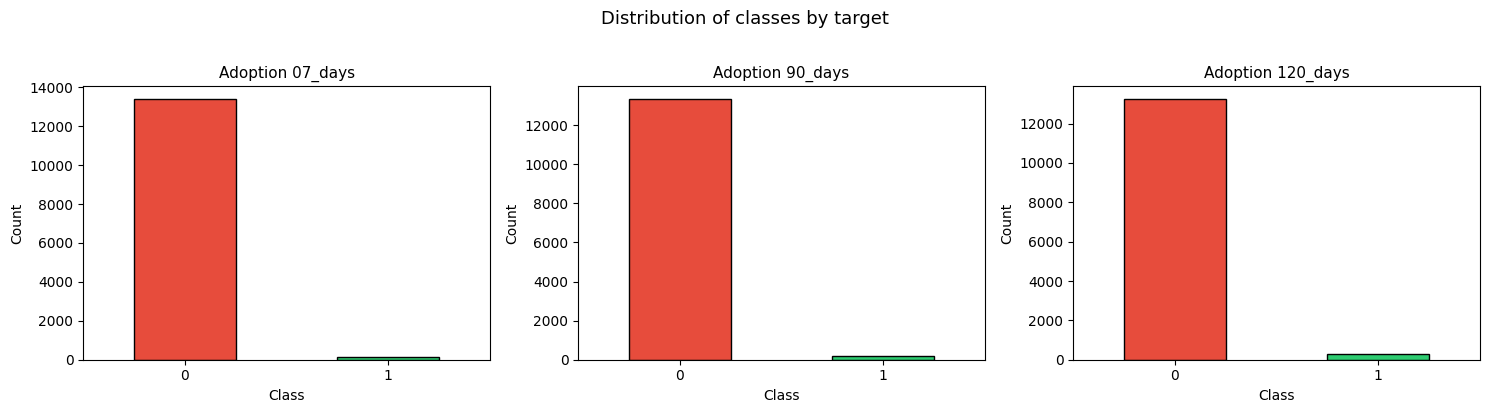

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, TARGETS):
    train[t].value_counts().plot(kind='bar', ax=ax,
                                  color=['#e74c3c', '#2ecc71'], edgecolor='black')
    ax.set_title(t.replace('adopted_within_', 'Adoption '), fontsize=11)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(rotation=0)
plt.suptitle('Distribution of classes by target', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

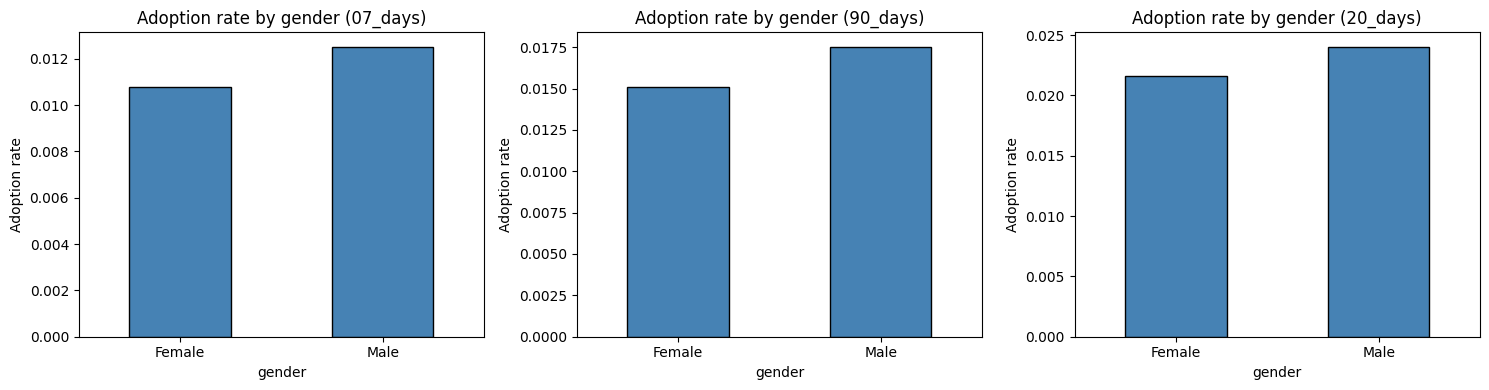

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, TARGETS):
    train.groupby('gender')[t].mean().plot(kind='bar', ax=ax,
                                            color='steelblue', edgecolor='black')
    ax.set_title(f'Adoption rate by gender ({t[-7:]})')
    ax.set_ylabel('Adoption rate')
    ax.tick_params(rotation=0)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [26]:
def parse_list_col(val):
    """Parse a column of list type (stored as string)."""
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(str(val))
    except:
        return []


def flatten_topics(val):
    """Flatten the list of topics (list of lists)."""
    items = parse_list_col(val)
    flat  = []
    for item in items:
        flat.extend(item) if isinstance(item, list) else flat.append(item)
    return flat


def engineer_features(df):
    df = df.copy()

    # Date
    df['training_day'] = pd.to_datetime(df['training_day'], errors='coerce')
    df['year']         = df['training_day'].dt.year
    df['month']        = df['training_day'].dt.month
    df['dayofweek']    = df['training_day'].dt.dayofweek
    df['dayofyear']    = df['training_day'].dt.dayofyear
    df['quarter']      = df['training_day'].dt.quarter
    df['is_weekend']   = (df['dayofweek'] >= 5).astype(int)

    # Trainer
    df['trainer_list']    = df['trainer'].apply(parse_list_col)
    df['num_trainers']    = df['trainer_list'].apply(len)
    df['primary_trainer'] = df['trainer_list'].apply(lambda x: x[0] if x else 'UNKNOWN')

    # Topics
    df['topic_list']        = df['topics_list'].apply(flatten_topics)
    df['num_topics']        = df['topic_list'].apply(len)
    df['num_unique_topics'] = df['topic_list'].apply(lambda x: len(set(x)))
    df['has_poultry']       = df['topic_list'].apply(lambda x: int(any('Poultry' in t for t in x)))
    df['has_herd']          = df['topic_list'].apply(lambda x: int(any('Herd'    in t for t in x)))
    df['has_dairy']         = df['topic_list'].apply(lambda x: int(any('Dairy'   in t or 'Milk' in t for t in x)))
    df['has_app']           = df['topic_list'].apply(lambda x: int(any('App'     in t for t in x)))

    # Interaction
    df['coop_gender'] = df['belong_to_cooperative'].astype(str) + '_' + df['gender'].fillna('Unknown')

    df.drop(columns=['training_day', 'trainer', 'topics_list',
                     'trainer_list', 'topic_list'], inplace=True, errors='ignore')
    return df


train_fe = engineer_features(train)
test_fe  = engineer_features(test)

In [27]:
# Encoding of categorical variables (train + test together for consistency)
cat_cols = ['gender', 'registration', 'age', 'group_name',
            'county', 'subcounty', 'ward', 'primary_trainer', 'coop_gender']

combined = pd.concat([train_fe, test_fe], axis=0, ignore_index=True)

for col in cat_cols:
    if col in combined.columns:
        combined[col] = combined[col].fillna('MISSING')
        le = LabelEncoder()
        combined[col] = le.fit_transform(combined[col].astype(str))

n_train   = len(train_fe)
train_enc = combined.iloc[:n_train].copy()
test_enc  = combined.iloc[n_train:].copy()

feature_cols = [c for c in train_enc.columns if c not in TARGETS + ['ID', 'farmer_name']]

X      = train_enc[feature_cols].copy()
X_test = test_enc[feature_cols].copy()

print(f'Features : {X.shape[1]} columns')
X.head(3)

Features : 24 columns


,gender,registration,age,group_name,belong_to_cooperative,county,subcounty,ward,has_topic_trained_on,year,month,dayofweek,dayofyear,quarter,is_weekend,num_trainers,primary_trainer,num_topics,num_unique_topics,has_poultry,has_herd,has_dairy,has_app,coop_gender
0,0,0,0,922,0,2,15,39,0,2024,1,2,3,1,0,1,6,2,2,1,0,0,1,0
1,0,0,0,936,1,0,16,1,1,2024,1,2,3,1,0,1,4,2,1,1,0,0,0,2
2,0,0,0,952,0,0,16,1,1,2024,1,2,3,1,0,1,4,29,29,1,0,1,0,0


## 5. Zindi Metric

In [28]:
def zindi_score(y_true, y_pred):
    """Zindi Score = 75% LogLoss + 25% ROC-AUC."""
    ll  = log_loss(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    return 0.75 * (1 - ll) + 0.25 * auc, ll, auc

## 6. LightGBM Training (5-Fold OOF)

In [29]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

lgb_params = {
    'objective'        : 'binary',
    'metric'           : ['binary_logloss', 'auc'],
    'learning_rate'    : 0.03,
    'num_leaves'       : 63,
    'max_depth'        : -1,
    'min_child_samples': 20,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 1.0,
    'n_estimators'     : 2000,
    'random_state'     : 42,
    'verbosity'        : -1,
    'is_unbalance'     : True,
}

oof_preds  = pd.DataFrame(index=train.index, columns=TARGETS, dtype=float)
test_preds = pd.DataFrame(0.0,              index=test.index,  columns=TARGETS)
cv_results = {}

In [30]:
for target in TARGETS:
    y = train_enc[target].values
    fold_test_preds = np.zeros(len(X_test))

    print(f'\nTarget : {target}')
    print('-' * 55)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model = lgb.LGBMClassifier(**lgb_params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(period=-1),
            ]
        )

        val_proba = model.predict_proba(X_val)[:, 1]
        oof_preds.loc[val_idx, target] = val_proba
        fold_test_preds += model.predict_proba(X_test)[:, 1] / N_FOLDS

        fold_ll  = log_loss(y_val, val_proba)
        fold_auc = roc_auc_score(y_val, val_proba)
        print(f'  Fold {fold}  |  LogLoss: {fold_ll:.5f}  |  AUC: {fold_auc:.5f}  |  Arbres: {model.best_iteration_}')

    test_preds[target] = fold_test_preds

    oof_ll  = log_loss(y, oof_preds[target])
    oof_auc = roc_auc_score(y, oof_preds[target])
    cv_results[target] = {'LogLoss': oof_ll, 'AUC': oof_auc}
    print(f'  OOF  |  LogLoss: {oof_ll:.5f}  |  AUC: {oof_auc:.5f}')


Target : adopted_within_07_days
-------------------------------------------------------
  Fold 1  |  LogLoss: 0.04943  |  AUC: 0.97863  |  Arbres: 10
  Fold 2  |  LogLoss: 0.05285  |  AUC: 0.92327  |  Arbres: 1
  Fold 3  |  LogLoss: 0.04762  |  AUC: 0.97988  |  Arbres: 215
  Fold 4  |  LogLoss: 0.04318  |  AUC: 0.98443  |  Arbres: 150
  Fold 5  |  LogLoss: 0.04445  |  AUC: 0.98362  |  Arbres: 216
  OOF  |  LogLoss: 0.04751  |  AUC: 0.96320

Target : adopted_within_90_days
-------------------------------------------------------
  Fold 1  |  LogLoss: 0.06512  |  AUC: 0.94476  |  Arbres: 4
  Fold 2  |  LogLoss: 0.05436  |  AUC: 0.98339  |  Arbres: 158
  Fold 3  |  LogLoss: 0.06812  |  AUC: 0.92287  |  Arbres: 3
  Fold 4  |  LogLoss: 0.06759  |  AUC: 0.94649  |  Arbres: 13
  Fold 5  |  LogLoss: 0.06656  |  AUC: 0.93320  |  Arbres: 6
  OOF  |  LogLoss: 0.06435  |  AUC: 0.93714

Target : adopted_within_120_days
-------------------------------------------------------
  Fold 1  |  LogLoss: 0.

## 7. LightGBM Evaluation

In [31]:
results_df = pd.DataFrame(cv_results).T
results_df['Zindi_Score'] = 0.75 * (1 - results_df['LogLoss']) + 0.25 * results_df['AUC']
results_df

,LogLoss,AUC,Zindi_Score
adopted_within_07_days,0.047507,0.963203,0.955170
adopted_within_90_days,0.064349,0.937143,0.936024
adopted_within_120_days,0.068462,0.965039,0.939913


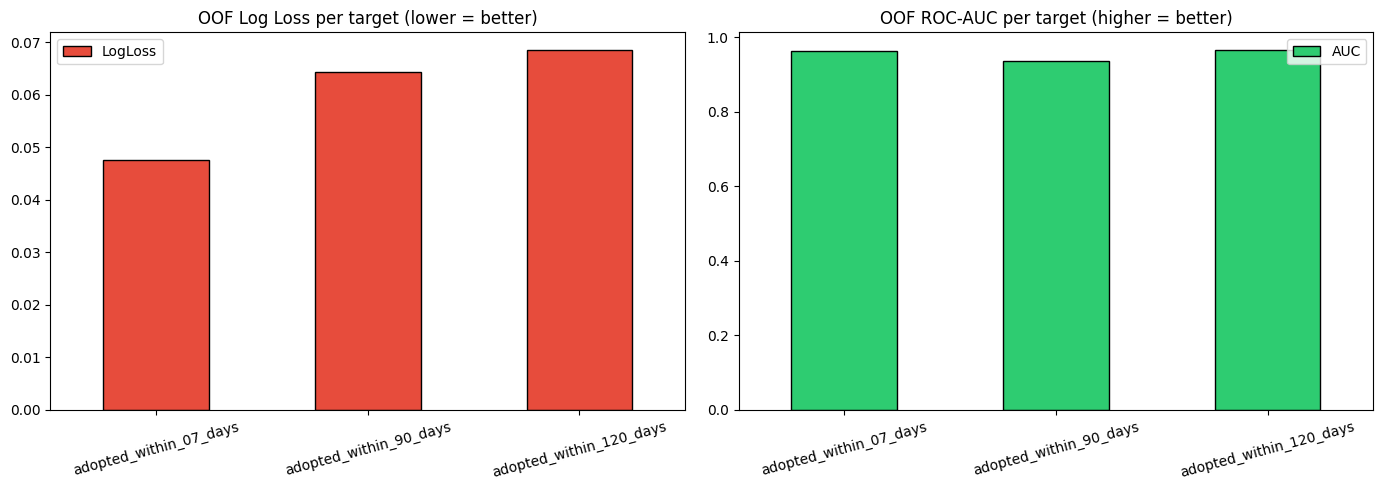

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[['LogLoss']].plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('OOF Log Loss per target (lower = better)', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

results_df[['AUC']].plot(kind='bar', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('OOF ROC-AUC per target (higher = better)', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 8. Feature Importance

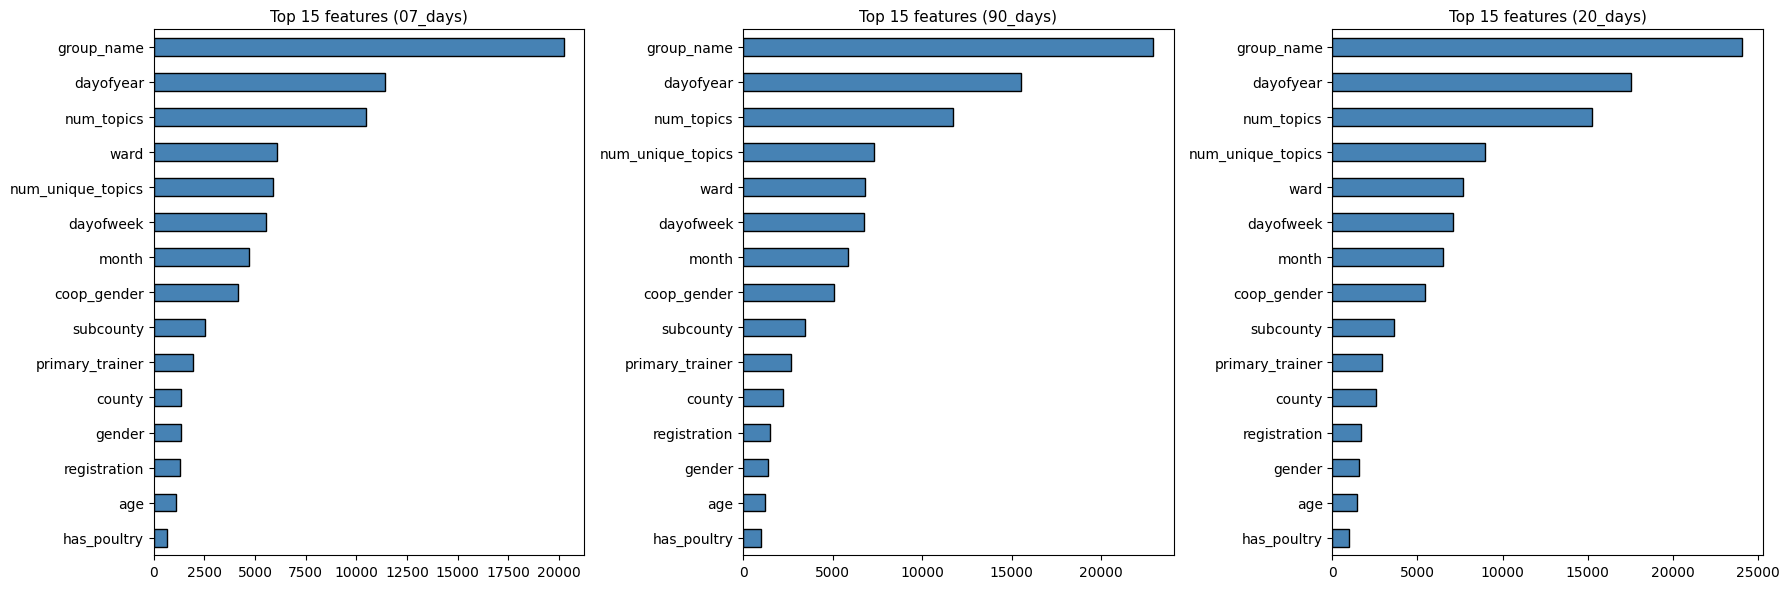

In [33]:
fi_models = {}
for target in TARGETS:
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(X, train_enc[target].values, callbacks=[lgb.log_evaluation(period=-1)])
    fi_models[target] = m

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, target in zip(axes, TARGETS):
    fi = pd.Series(fi_models[target].feature_importances_, index=feature_cols)
    fi.nlargest(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Top 15 features ({target[-7:]})', fontsize=11)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. XGBoost Training (ensemble)

In [34]:
xgb_params = {
    'objective'          : 'binary:logistic',
    'eval_metric'        : 'logloss',
    'learning_rate'      : 0.03,
    'max_depth'          : 6,
    'subsample'          : 0.8,
    'colsample_bytree'   : 0.8,
    'reg_alpha'          : 0.1,
    'reg_lambda'         : 1.0,
    'n_estimators'       : 2000,
    'random_state'       : 42,
    'early_stopping_rounds': 100,
    'verbosity'          : 0,
    'tree_method'        : 'hist',
}

oof_xgb  = pd.DataFrame(index=train.index, columns=TARGETS, dtype=float)
test_xgb = pd.DataFrame(0.0,              index=test.index,  columns=TARGETS)

for target in TARGETS:
    y   = train_enc[target].values
    spw = (y == 0).sum() / (y == 1).sum()   # weight to compensate for imbalance
    fold_test_preds = np.zeros(len(X_test))

    print(f'\nTarget : {target}')
    print('-' * 55)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        params = {**xgb_params, 'scale_pos_weight': spw}
        model  = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        val_proba = model.predict_proba(X_val)[:, 1]
        oof_xgb.loc[val_idx, target] = val_proba
        fold_test_preds += model.predict_proba(X_test)[:, 1] / N_FOLDS

        fold_ll  = log_loss(y_val, val_proba)
        fold_auc = roc_auc_score(y_val, val_proba)
        print(f'  Fold {fold}  |  LogLoss: {fold_ll:.5f}  |  AUC: {fold_auc:.5f}')

    test_xgb[target] = fold_test_preds
    oof_ll  = log_loss(y, oof_xgb[target])
    oof_auc = roc_auc_score(y, oof_xgb[target])
    print(f'  OOF  |  LogLoss: {oof_ll:.5f}  |  AUC: {oof_auc:.5f}')


Target : adopted_within_07_days
-------------------------------------------------------
  Fold 1  |  LogLoss: 0.03552  |  AUC: 0.98373
  Fold 2  |  LogLoss: 0.05958  |  AUC: 0.96256
  Fold 3  |  LogLoss: 0.04760  |  AUC: 0.97680
  Fold 4  |  LogLoss: 0.03811  |  AUC: 0.98443
  Fold 5  |  LogLoss: 0.04053  |  AUC: 0.97897
  OOF  |  LogLoss: 0.04426  |  AUC: 0.97727

Target : adopted_within_90_days
-------------------------------------------------------
  Fold 1  |  LogLoss: 0.05002  |  AUC: 0.98234
  Fold 2  |  LogLoss: 0.05691  |  AUC: 0.96737
  Fold 3  |  LogLoss: 0.07914  |  AUC: 0.95392
  Fold 4  |  LogLoss: 0.04945  |  AUC: 0.94449
  Fold 5  |  LogLoss: 0.06320  |  AUC: 0.95454
  OOF  |  LogLoss: 0.05974  |  AUC: 0.96042

Target : adopted_within_120_days
-------------------------------------------------------
  Fold 1  |  LogLoss: 0.05766  |  AUC: 0.98443
  Fold 2  |  LogLoss: 0.07604  |  AUC: 0.94800
  Fold 3  |  LogLoss: 0.07626  |  AUC: 0.94024
  Fold 4  |  LogLoss: 0.06736  | 

## 10. Blending LightGBM + XGBoost

In [35]:
# Search for optimal weights (LGB vs XGB) via OOF score
best_weights = {}

for target in TARGETS:
    y = train_enc[target].values
    best_ll, best_w = np.inf, 0.5

    for w in np.linspace(0, 1, 21):
        blend = w * oof_preds[target] + (1 - w) * oof_xgb[target]
        ll = log_loss(y, blend)
        if ll < best_ll:
            best_ll, best_w = ll, w

    best_weights[target] = best_w
    blend_oof = best_w * oof_preds[target] + (1 - best_w) * oof_xgb[target]
    blend_auc = roc_auc_score(y, blend_oof)
    print(f'{target}  |  LGB_weight={best_w:.2f}  |  LogLoss={best_ll:.5f}  |  AUC={blend_auc:.5f}')

# Apply blend to test data
test_blend = pd.DataFrame(index=test.index, columns=TARGETS)
for target in TARGETS:
    w = best_weights[target]
    test_blend[target] = w * test_preds[target] + (1 - w) * test_xgb[target]

adopted_within_07_days  |  LGB_weight=0.30  |  LogLoss=0.03877  |  AUC=0.97784
adopted_within_90_days  |  LGB_weight=0.30  |  LogLoss=0.04938  |  AUC=0.95892
adopted_within_120_days  |  LGB_weight=0.30  |  LogLoss=0.06463  |  AUC=0.96551


## 11. Final Results

In [36]:
summary = []
for target in TARGETS:
    y = train_enc[target].values
    w = best_weights[target]
    blend_oof = w * oof_preds[target] + (1 - w) * oof_xgb[target]
    ll  = log_loss(y, blend_oof)
    auc = roc_auc_score(y, blend_oof)
    summary.append({'Target': target, 'LogLoss': ll, 'AUC': auc,
                    'Zindi_Score': 0.75*(1-ll) + 0.25*auc})

summary_df = pd.DataFrame(summary).set_index('Target')
summary_df

,LogLoss,AUC,Zindi_Score
Target,,,
adopted_within_07_days,0.038772,0.977845,0.965382
adopted_within_90_days,0.049380,0.958925,0.952696
adopted_within_120_days,0.064627,0.965510,0.942907


## 12. Submission File

In [37]:
submission = pd.DataFrame({'ID': test['ID']})

tag_map = {
    'adopted_within_07_days' : '07',
    'adopted_within_90_days' : '90',
    'adopted_within_120_days': '120',
}

for target, tag in tag_map.items():
    p = np.clip(test_blend[target].values.astype(float), 1e-6, 1 - 1e-6)
    submission[f'Target_{tag}_AUC']     = p
    submission[f'Target_{tag}_LogLoss'] = p

# Column order in accordance with SampleSubmission
submission = submission[['ID',
    'Target_07_AUC', 'Target_90_AUC', 'Target_120_AUC',
    'Target_07_LogLoss', 'Target_90_LogLoss', 'Target_120_LogLoss']]

submission.to_csv('submission.csv', index=False)
print(f'submission.csv saved  ({submission.shape[0]} rows x {submission.shape[1]} columns)')
submission.head()

submission.csv saved  (5621 rows x 7 columns)


,ID,Target_07_AUC,Target_90_AUC,Target_120_AUC,Target_07_LogLoss,Target_90_LogLoss,Target_120_LogLoss
0,ID_LEG1GM,0.001206,0.013879,0.002317,0.001206,0.013879,0.002317
1,ID_1UKOKW,0.001301,0.003408,0.000126,0.001301,0.003408,0.000126
2,ID_U5H2YK,0.023874,0.023905,0.007278,0.023874,0.023905,0.007278
3,ID_55957A,0.015743,0.021224,0.003488,0.015743,0.021224,0.003488
4,ID_N1AC0A,0.001270,0.003195,0.000083,0.001270,0.003195,0.000083
